In [1]:
import numpy as np
from sklearn.neural_network import BernoulliRBM
X = np.array([[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
model = BernoulliRBM(n_components=2)
model.fit(X)

BernoulliRBM(n_components=2)

In [2]:
model.get_params()

{'batch_size': 10,
 'learning_rate': 0.1,
 'n_components': 2,
 'n_iter': 10,
 'random_state': None,
 'verbose': 0}

In [2]:
import numpy as np
from gaussian_rbm import GaussianRBM
X = np.array([[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
model = GaussianRBM(n_components=2)
model.fit(X)

GaussianRBM(n_components=2)

In [3]:
import numpy as np
from gaussian_softmax_rbm import GaussianSoftmaxRBM
X = np.array([[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
model = GaussianSoftmaxRBM(n_components=2)
model.fit(X)

GaussianSoftmaxRBM(n_components=2)

In [6]:
import numpy as np
from bernoulli_softmax_rbm import BernoulliSoftmaxRBM
X = np.array([[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
model = BernoulliSoftmaxRBM(n_components=2)
model.fit(X)

BernoulliSoftmaxRBM()

In [24]:
import numpy as np
from dbn_builder import build_unsupervised_dbn
X = np.array([[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 1]])
dbn_model = build_unsupervised_dbn(input_type="gaussian", latent_type="softmax")
dbn_model.fit(X)

Pipeline(steps=[('rbm1',
                 GaussianRBM(learning_rate=0.06, n_components=512,
                             random_state=0, verbose=False)),
                ('rbm2',
                 BernoulliSoftmaxRBM(learning_rate=0.06, random_state=1,
                                     verbose=False))])

MAE for all 0 selection: tensor(0.1307)

Training RBM Layer 1 gaussian_rbm_1 with 500 hidden units


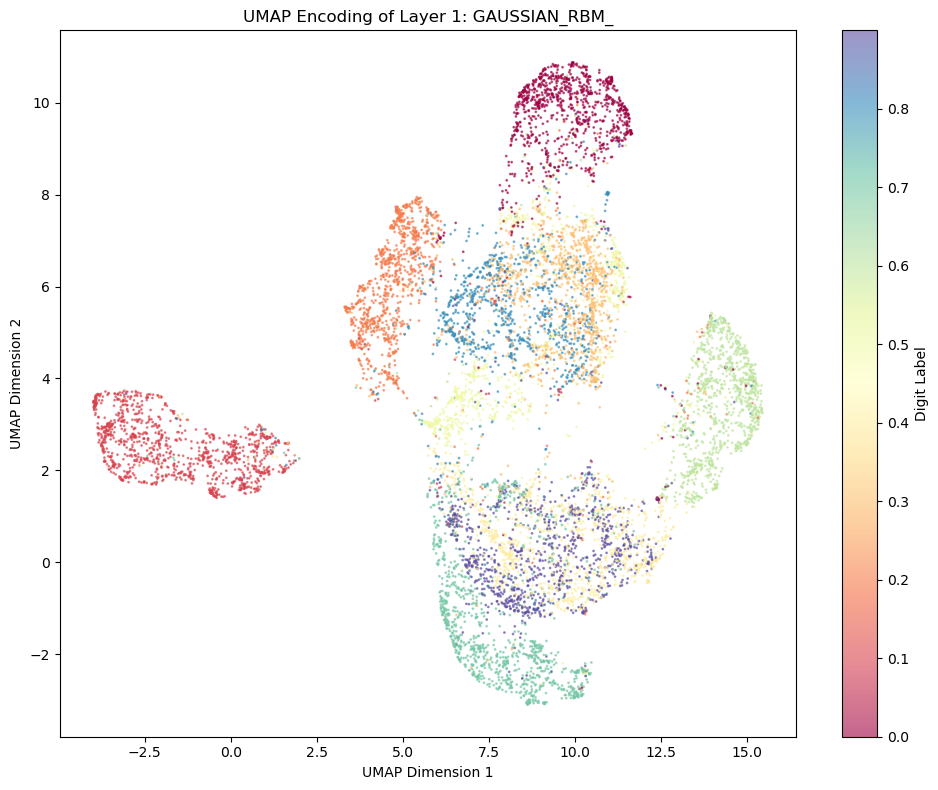


Training RBM Layer 2 gaussian_rbm_2 with 300 hidden units


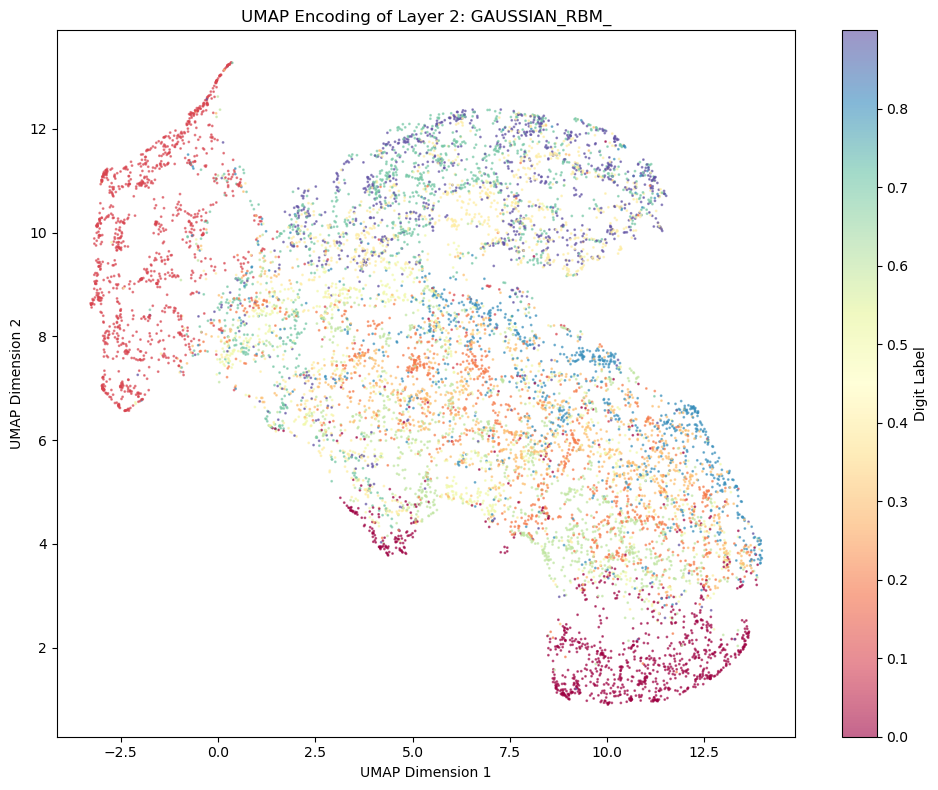


Training RBM Layer 3 softmax_rbm_3 with 100 hidden units


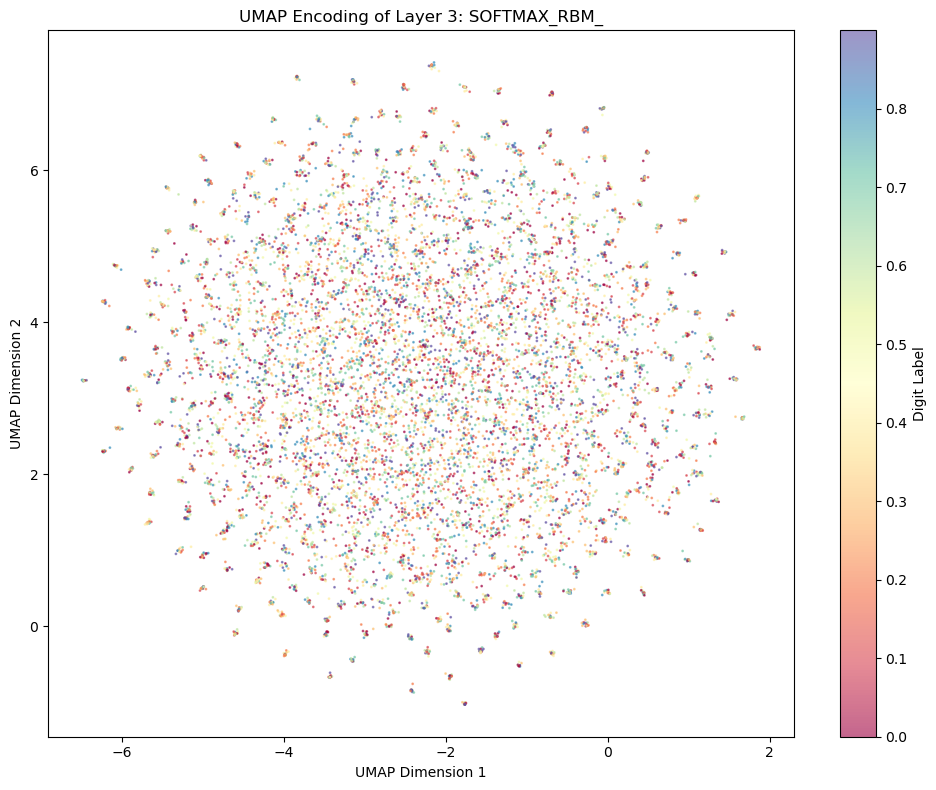

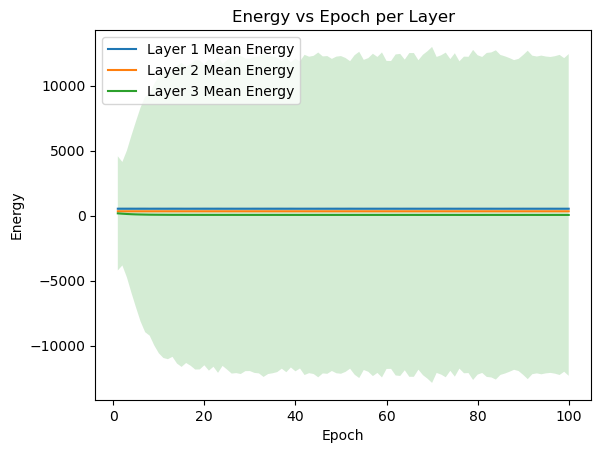

In [3]:
from load_dataset import MNIST
from torch.utils.data import DataLoader, TensorDataset
import torch
from utils import create_dataloader
from train import fit_dataloader
from dbn_builder import build_unsupervised_dbn


mnist = MNIST()
train_x, train_y, test_x, test_y = mnist.load_dataset(binary_status=False)
train_y = train_y/10.
print('MAE for all 0 selection:', torch.mean(train_x))

sample_size = 10000
batch_size = 100
epochs = 100
data_loader = create_dataloader(train_x[:sample_size], train_y[:sample_size], batch_size)
dbn_model = build_unsupervised_dbn(rbm_layer_sizes=[500, 300, 100], input_type="gaussian", intermediate_type="gaussian", latent_type="softmax")

fit_dataloader(data_loader, dbn_model, epochs)




In [2]:
rbm_types =  [step[0] for step in dbn_model.steps]
rbm_types

['gaussian_rbm_1', 'gaussian_rbm_2', 'softmax_rbm_3']

In [1]:
from utils import clip_gradients

In [63]:
import pandas as pd


train = pd.read_csv('../data/MNIST/'+'train.csv')
train = train.values
train_x = train.T[1:].T
train_y = train.T[0]
train_x = (train_x - np.min(train_x))/(np.max(train_x) - np.min(train_x))
mnist = MNIST()
train_x, train_y, test_x, test_y = mnist.load_dataset()

In [64]:
def has_non_binary_values(arr):
    return not np.all((arr == 0.0) | (arr == 1.0))
def get_non_binary_values(arr):
    mask = (arr != 0.0) & (arr != 1.0)
    return arr[mask]
get_non_binary_values(train_x)

tensor([0.0118, 0.0706, 0.0706,  ..., 0.7569, 0.7725, 0.5255])